# SV-SNP LD tagging — arch3 panel vs GrENE-Net short-read SNPs

**Question:** in the current production (arch3) 231-founder panel, how well are
structural variants (>50bp) tagged by the nearest SNP within &plusmn;50kb — and how
much of that tagging is actually coming from arch3's own denser SNP catalog, vs
what the old GrENE-Net SNP-only catalog (`greneNet_final_v1.1`, no SVs) could
already see?

Two r&sup2; scans, same SV set, same founders, same &plusmn;50kb window, computed by
`analysis/grenenet_gea/build_sv_snp_ld.py`:

- **panel** &mdash; each SV's max founder-genotype r&sup2; against SNPs from arch3's own
  merged catalog (`var_pa_231_arch3`)
- **shortread** &mdash; the same SVs against SNPs from the old GrENE-Net SNP-only VCF
  (`greneNet_final_v1.1`, founder-aligned)

r&sup2; = squared Pearson correlation of the SV-presence vector vs SNP alt-dosage
vector over the 231 founders. All 5 chromosomes, genome-wide.

**Note on the prior analysis:** an earlier version of this question was answered
in `preprocess_qc/notebooks/ld_comparison.ipynb` / `ld_full_comparison.ipynb` /
`ld_sv_snp_histograms.ipynb`, but on the **pre-arch3** merged panel
(`founders_231_chr.vcf.gz`). That analysis is now archived
(`archive/preprocess_qc/`) since arch3 replaced that panel build; this notebook
answers the same question on current production data.


In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

PROJ = "/global/scratch/users/tbellg/kmate"
LD = f"{PROJ}/analysis/grenenet_gea/sv_snp_ld"
CHROMS = ["Chr1", "Chr2", "Chr3", "Chr4", "Chr5"]

# --- style: light-mode, quiet chrome (dataviz skill defaults) ---
ACCENT = "#2a78d6"   # arch3 panel SNPs (blue, palette slot 1) -- the "new" series
BASE   = "#7f8da6"   # GrENE-Net short-read SNPs (muted gray-blue) -- the "old" series
INK        = "#0b0b0b"
INK_MUTED  = "#898781"
GRID       = "#e1e0d9"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": INK_MUTED, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "figure.dpi": 110,
})

def size_class(sv_size):
    sv_size = np.asarray(sv_size)
    cls = np.full(sv_size.shape, "large_sv", dtype=object)
    cls[sv_size < 5000] = "medium_sv"
    cls[sv_size < 500] = "small_sv"
    return cls

rows = []
for chrom in CHROMS:
    zp = np.load(f"{LD}/sv_snp_ld_panel_{chrom}.npz", allow_pickle=True)
    zs = np.load(f"{LD}/sv_snp_ld_shortread_{chrom}.npz", allow_pickle=True)
    assert np.array_equal(zp["pos"], zs["pos"]), "panel/shortread SV sets must align"
    rows.append(pd.DataFrame({
        "chrom": chrom, "pos": zp["pos"], "sv_size": zp["sv_size"],
        "sv_class": size_class(zp["sv_size"]),
        "r2_panel": zp["best_r2"], "r2_shortread": zs["best_r2"],
    }))
df = pd.concat(rows, ignore_index=True)
print(f"{len(df):,} SVs genome-wide (Chr1-5), arch3 production panel")
print(df.sv_class.value_counts().rename("n"))

226,468 SVs genome-wide (Chr1-5), arch3 production panel
sv_class
medium_sv    102418
small_sv      97214
large_sv      26836
Name: n, dtype: int64


## 1. Distribution of best r²

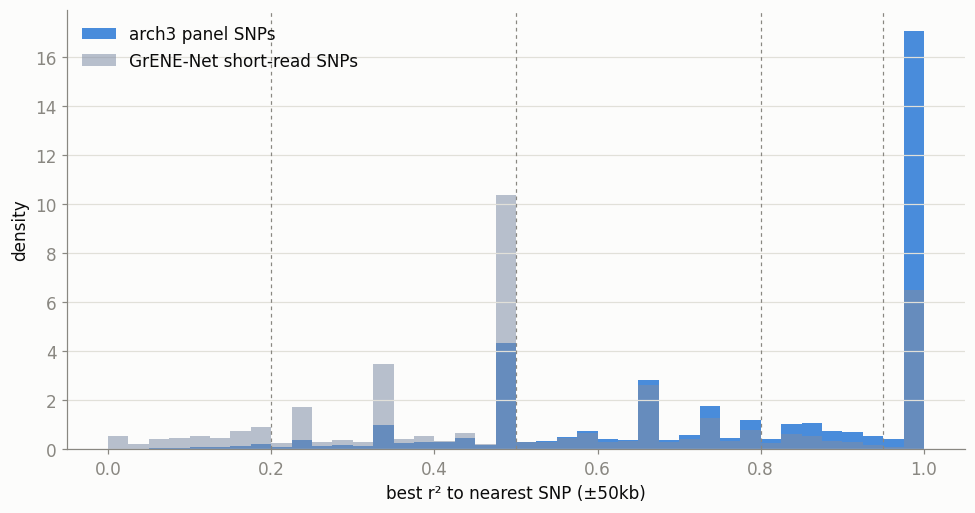

In [2]:
# 1. Distribution of best r2 -- panel vs shortread
fig, ax = plt.subplots(figsize=(9, 4.8))
bins = np.linspace(0, 1, 41)
ax.hist(df.r2_panel.dropna(),     bins=bins, color=ACCENT, alpha=0.85, label="arch3 panel SNPs",        density=True)
ax.hist(df.r2_shortread.dropna(), bins=bins, color=BASE,   alpha=0.55, label="GrENE-Net short-read SNPs", density=True)
for t in (0.2, 0.5, 0.8, 0.95):
    ax.axvline(t, color=INK_MUTED, lw=0.8, ls=(0, (3, 3)))
ax.set_xlabel("best r² to nearest SNP (±50kb)"); ax.set_ylabel("density")
ax.legend(frameon=False, loc="upper left")
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

## 2. Survival curve (headline tagging rate, continuous)

 threshold  panel_pct  shortread_pct
      0.20       99.6           92.7
      0.50       93.5           60.9
      0.80       85.8           47.4
      0.95       82.3           43.7


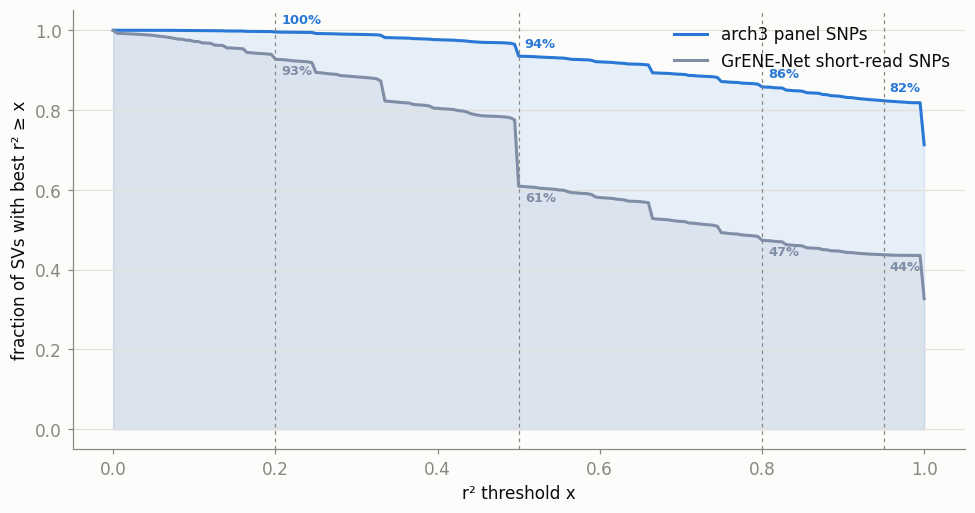

In [3]:
# 2. Survival curve: fraction of SVs with r2 >= x -- continuous version of the
# headline threshold table (the discrete 4-bar version was redundant with this
# and was dropped; the same threshold values are now annotated directly here).
xs = np.linspace(0, 1, 201)
surv_panel     = np.array([(df.r2_panel     >= x).mean() for x in xs])
surv_shortread = np.array([(df.r2_shortread >= x).mean() for x in xs])

thresholds = [0.2, 0.5, 0.8, 0.95]
headline = pd.DataFrame({
    "threshold": thresholds,
    "panel_pct":     [100*surv_panel[np.argmin(np.abs(xs - t))] for t in thresholds],
    "shortread_pct": [100*surv_shortread[np.argmin(np.abs(xs - t))] for t in thresholds],
})
print(headline.round({"panel_pct": 1, "shortread_pct": 1}).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(xs, surv_panel,     color=ACCENT, lw=2, label="arch3 panel SNPs")
ax.fill_between(xs, surv_panel, color=ACCENT, alpha=0.10)
ax.plot(xs, surv_shortread, color=BASE,   lw=2, label="GrENE-Net short-read SNPs")
ax.fill_between(xs, surv_shortread, color=BASE, alpha=0.10)
for _, row in headline.iterrows():
    t = row.threshold
    ax.axvline(t, color=INK_MUTED, lw=0.8, ls=(0, (3, 3)))
    ax.annotate(f"{row.panel_pct:.0f}%", (t, row.panel_pct/100), xytext=(4, 6),
                textcoords="offset points", fontsize=8.5, color=ACCENT, fontweight="bold")
    ax.annotate(f"{row.shortread_pct:.0f}%", (t, row.shortread_pct/100), xytext=(4, -10),
                textcoords="offset points", fontsize=8.5, color=BASE, fontweight="bold")
ax.set_xlabel("r² threshold x"); ax.set_ylabel("fraction of SVs with best r² ≥ x")
ax.legend(frameon=False, loc="upper right")
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

## 3. Paired per-SV comparison

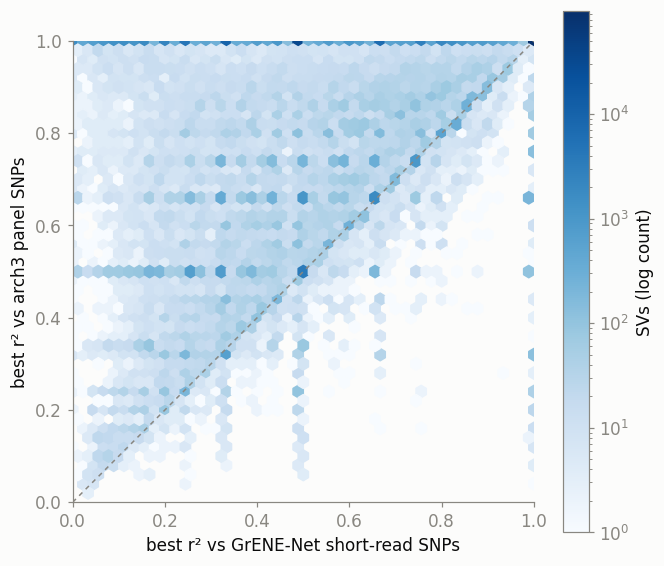

88,428 SVs (39.0%) cross the r²>0.8 'well-tagged' bar with arch3 SNPs but NOT with GrENE-Net short-read SNPs alone --
these are exactly the SVs a SNP-only (GrENE-Net-style) GEA would under-tag.


In [4]:
# 3. Paired per-SV comparison: same SV, panel r2 vs shortread r2
fig, ax = plt.subplots(figsize=(6.2, 6))
hb = ax.hexbin(df.r2_shortread, df.r2_panel, gridsize=45, mincnt=1,
                cmap="Blues", bins="log", extent=(0, 1, 0, 1))
ax.plot([0, 1], [0, 1], color=INK_MUTED, lw=1, ls=(0, (3, 3)))
ax.set_xlabel("best r² vs GrENE-Net short-read SNPs")
ax.set_ylabel("best r² vs arch3 panel SNPs")
cb = fig.colorbar(hb, ax=ax, label="SVs (log count)", shrink=0.85)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
ax.grid(visible=False)
plt.tight_layout(); plt.show()

gain = df.r2_panel - df.r2_shortread
n_gain_bin = int(((df.r2_panel > 0.8) & (df.r2_shortread <= 0.8)).sum())
print(f"{n_gain_bin:,} SVs ({100*n_gain_bin/len(df):.1f}%) cross the r²>0.8 'well-tagged' "
      f"bar with arch3 SNPs but NOT with GrENE-Net short-read SNPs alone --")
print("these are exactly the SVs a SNP-only (GrENE-Net-style) GEA would under-tag.")